In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Crop recommendation dataset.csv to Crop recommendation dataset (1).csv


In [ ]:
df = pd.read_csv("Crop recommendation dataset.csv")
print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (57000, 23)
['CROPS', 'TYPE_OF_CROP', 'SOIL', 'SEASON', 'SOWN', 'HARVESTED', 'WATER_SOURCE', 'SOIL_PH', 'SOIL_PH_HIGH', 'CROPDURATION', 'CROPDURATION_MAX', 'TEMP', 'MAX_TEMP', 'WATERREQUIRED', 'WATERREQUIRED_MAX', 'RELATIVE_HUMIDITY', 'RELATIVE_HUMIDITY_MAX', 'N', 'N_MAX', 'P', 'P_MAX', 'K', 'K_MAX']


,CROPS,TYPE_OF_CROP,SOIL,SEASON,SOWN,HARVESTED,WATER_SOURCE,SOIL_PH,SOIL_PH_HIGH,CROPDURATION,...,WATERREQUIRED,WATERREQUIRED_MAX,RELATIVE_HUMIDITY,RELATIVE_HUMIDITY_MAX,N,N_MAX,P,P_MAX,K,K_MAX
0,rice,cereals,Alluvial soil,kharif,Jun,Sep,irrigated,7.6,8.0,116.9,...,2462.3,2500,73.8,80,82.4,100,40.7,60,42.2,60
1,rice,cereals,Loamy soil,kharif,Jul,Oct,rainfed,6.2,8.0,117.9,...,1237.5,2500,60.9,80,90.5,100,51.3,60,46.2,60
2,rice,cereals,Clay soil,kharif,Jun,Sep,irrigated,6.7,8.0,117.7,...,1075.1,2500,67.5,80,86.2,100,50.7,60,44.4,60
3,rice,cereals,Alluvial soil,kharif,Jul,Oct,rainfed,6.1,8.0,149.8,...,1549.9,2500,73.6,80,91.3,100,51.3,60,44.5,60
4,rice,cereals,Loamy soil,kharif,Jun,Sep,irrigated,8.0,8.0,131.7,...,1306.4,2500,60.3,80,81.3,100,48.6,60,51.0,60


In [ ]:
selected_columns = [
    'CROPS',
    'SOIL',
    'SEASON',
    'WATER_SOURCE',
    'SOIL_PH',
    'TEMP',
    'RELATIVE_HUMIDITY',
    'N',
    'P',
    'K'
]

data = df[selected_columns].copy()
print("New shape:", data.shape)
data.head()

New shape: (57000, 10)


,CROPS,SOIL,SEASON,WATER_SOURCE,SOIL_PH,TEMP,RELATIVE_HUMIDITY,N,P,K
0,rice,Alluvial soil,kharif,irrigated,7.6,26.9,73.8,82.4,40.7,42.2
1,rice,Loamy soil,kharif,rainfed,6.2,35.8,60.9,90.5,51.3,46.2
2,rice,Clay soil,kharif,irrigated,6.7,34.9,67.5,86.2,50.7,44.4
3,rice,Alluvial soil,kharif,rainfed,6.1,28.3,73.6,91.3,51.3,44.5
4,rice,Loamy soil,kharif,irrigated,8.0,26.3,60.3,81.3,48.6,51.0


In [ ]:
print(data.info())
print("\nMissing values:\n", data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CROPS              57000 non-null  object 
 1   SOIL               57000 non-null  object 
 2   SEASON             57000 non-null  object 
 3   WATER_SOURCE       57000 non-null  object 
 4   SOIL_PH            57000 non-null  float64
 5   TEMP               57000 non-null  float64
 6   RELATIVE_HUMIDITY  57000 non-null  float64
 7   N                  57000 non-null  float64
 8   P                  57000 non-null  float64
 9   K                  57000 non-null  float64
dtypes: float64(6), object(4)
memory usage: 4.3+ MB
None

Missing values:
 CROPS                0
SOIL                 0
SEASON               0
WATER_SOURCE         0
SOIL_PH              0
TEMP                 0
RELATIVE_HUMIDITY    0
N                    0
P                    0
K                    0
dtype: int

In [ ]:
data = data.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (57000, 10)


In [ ]:
eps = 1e-6

data['NPK_SUM'] = data['N'] + data['P'] + data['K']
data['NPK_MEAN'] = data[['N', 'P', 'K']].mean(axis=1)
data['NPK_STD'] = data[['N', 'P', 'K']].std(axis=1)

data['N_P_RATIO'] = data['N'] / (data['P'] + eps)
data['N_K_RATIO'] = data['N'] / (data['K'] + eps)
data['P_K_RATIO'] = data['P'] / (data['K'] + eps)

data['TEMP_PH_INTERACTION'] = data['TEMP'] * data['SOIL_PH']
data['HUMIDITY_TEMP_RATIO'] = data['RELATIVE_HUMIDITY'] / (data['TEMP'] + eps)

def fertility_class(x):
    if x < 120:
        return "Low"
    elif x < 220:
        return "Medium"
    else:
        return "High"

data['SOIL_FERTILITY_CLASS'] = data['NPK_SUM'].apply(fertility_class)

data.head()

,CROPS,SOIL,SEASON,WATER_SOURCE,SOIL_PH,TEMP,RELATIVE_HUMIDITY,N,P,K,NPK_SUM,NPK_MEAN,NPK_STD,N_P_RATIO,N_K_RATIO,P_K_RATIO,TEMP_PH_INTERACTION,HUMIDITY_TEMP_RATIO,SOIL_FERTILITY_CLASS
0,rice,Alluvial soil,kharif,irrigated,7.6,26.9,73.8,82.4,40.7,42.2,165.3,55.100000,23.654386,2.024570,1.952607,0.964455,204.44,2.743494,Medium
1,rice,Loamy soil,kharif,rainfed,6.2,35.8,60.9,90.5,51.3,46.2,188.0,62.666667,24.238881,1.764133,1.958874,1.110390,221.96,1.701117,Medium
2,rice,Clay soil,kharif,irrigated,6.7,34.9,67.5,86.2,50.7,44.4,181.3,60.433333,22.535823,1.700197,1.941441,1.141892,233.83,1.934097,Medium
3,rice,Alluvial soil,kharif,rainfed,6.1,28.3,73.6,91.3,51.3,44.5,187.1,62.366667,25.286624,1.779727,2.051685,1.152809,172.63,2.600707,Medium
4,rice,Loamy soil,kharif,irrigated,8.0,26.3,60.3,81.3,48.6,51.0,180.9,60.300000,18.226080,1.672839,1.594118,0.952941,210.40,2.292776,Medium


In [ ]:
print("Number of crop classes:", data['CROPS'].nunique())
print(data['CROPS'].value_counts().head(10))

Number of crop classes: 57
CROPS
rice            1000
wheat           1000
maize           1000
sorghum         1000
Pearl millet    1000
ragi            1000
panivaragu      1000
samai           1000
thinai          1000
varagu          1000
Name: count, dtype: int64


In [ ]:
X = data.drop('CROPS', axis=1)
y = data['CROPS']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (57000, 18)
y shape: (57000,)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Total classes:", len(label_encoder.classes_))
print("Sample classes:", label_encoder.classes_[:10])

Total classes: 57
Sample classes: ['Cabbage' 'Pearl millet' 'annual moringa' 'ash gourd' 'beetroot'
 'bengalgram' 'bhendi' 'bitter gourd' 'blackgram' 'bottle gourd']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (45600, 18)
X_test: (11400, 18)


In [ ]:
categorical_cols = ['SOIL', 'SEASON', 'WATER_SOURCE', 'SOIL_FERTILITY_CLASS']

numerical_cols = [
    'SOIL_PH',
    'TEMP',
    'RELATIVE_HUMIDITY',
    'N',
    'P',
    'K',
    'NPK_SUM',
    'NPK_MEAN',
    'NPK_STD',
    'N_P_RATIO',
    'N_K_RATIO',
    'P_K_RATIO',
    'TEMP_PH_INTERACTION',
    'HUMIDITY_TEMP_RATIO'
]

X_train_processed = pd.get_dummies(X_train, columns=categorical_cols)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols)

X_train_processed, X_test_processed = X_train_processed.align(
    X_test_processed,
    join='outer',
    axis=1,
    fill_value=0
)

scaler = StandardScaler()
X_train_processed[numerical_cols] = scaler.fit_transform(X_train_processed[numerical_cols])
X_test_processed[numerical_cols] = scaler.transform(X_test_processed[numerical_cols])

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (45600, 56)
Processed test shape: (11400, 56)


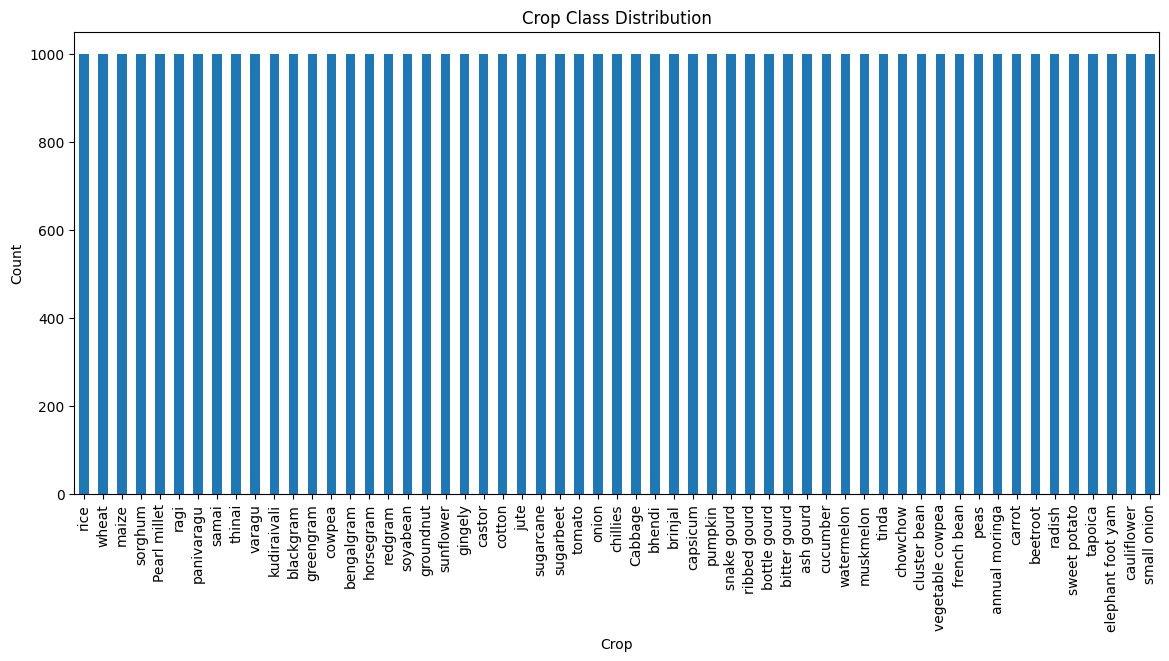

In [ ]:
plt.figure(figsize=(14,6))
data['CROPS'].value_counts().plot(kind='bar')
plt.title("Crop Class Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

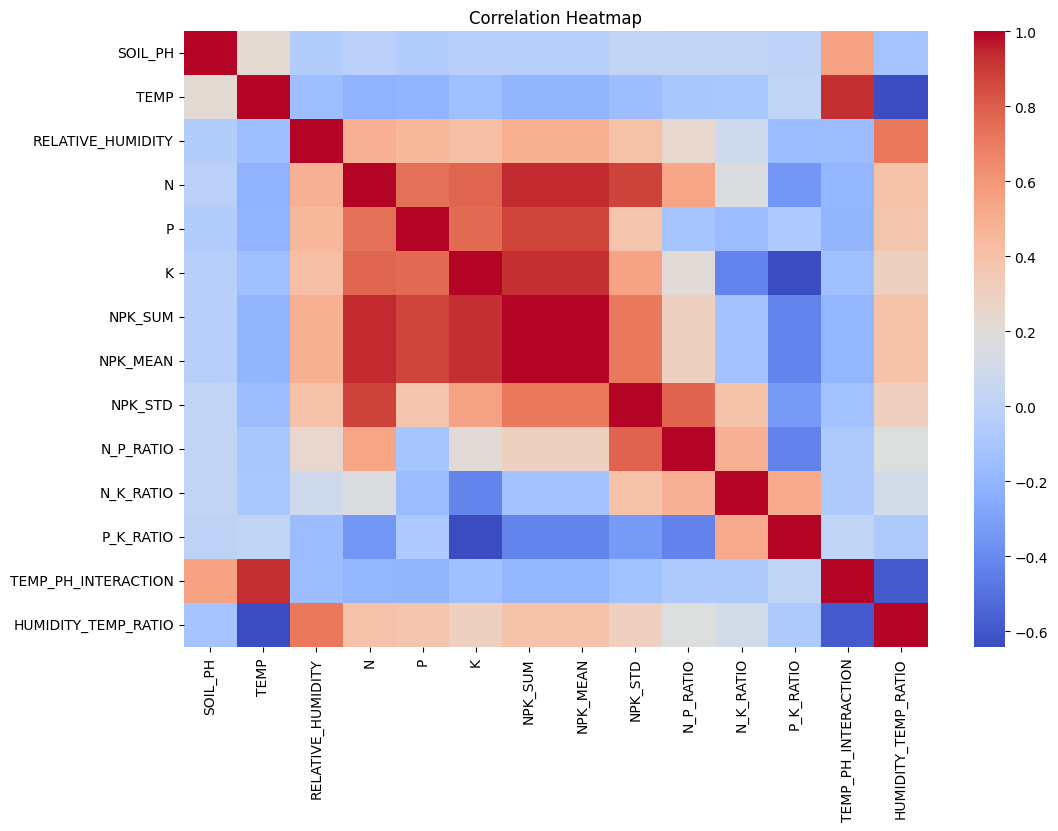

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data[numerical_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
input_dim = X_train_processed.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),

    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 57)             │         1,881 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,281 (79.22 KB)

 Trainable params: 19,897 (77.72 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    X_train_processed,
    y_train,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1949 - loss: 3.3432 - val_accuracy: 0.7669 - val_loss: 1.8940 - learning_rate: 0.0010
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7700 - loss: 0.8693 - val_accuracy: 0.9167 - val_loss: 0.4661 - learning_rate: 0.0010
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8793 - loss: 0.3981 - val_accuracy: 0.9378 - val_loss: 0.2095 - learning_rate: 0.0010
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9082 - loss: 0.2794 - val_accuracy: 0.9548 - val_loss: 0.1317 - learning_rate: 0.0010
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9226 - loss: 0.2274 - val_accuracy: 0.9591 - val_loss: 0.1064 - learning_rate: 0.0010
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9305 - loss: 0.1995 - val_accuracy: 0.9603 - val_loss: 0.0962 - learning_rate: 0.0010
Epoch 7/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9362 - loss: 0.1768 - 

In [ ]:
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.06202274188399315
Test Accuracy: 0.9740350842475891


In [ ]:
y_pred = model.predict(X_test_processed, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=label_encoder.classes_
))

                   precision    recall  f1-score   support

          Cabbage       1.00      1.00      1.00       200
     Pearl millet       1.00      0.94      0.97       200
   annual moringa       0.99      0.86      0.92       200
        ash gourd       0.98      0.98      0.98       200
         beetroot       1.00      1.00      1.00       200
       bengalgram       1.00      1.00      1.00       200
           bhendi       0.99      1.00      1.00       200
     bitter gourd       1.00      1.00      1.00       200
        blackgram       1.00      1.00      1.00       200
     bottle gourd       0.95      0.95      0.95       200
          brinjal       0.88      0.97      0.92       200
         capsicum       0.97      0.87      0.92       200
           carrot       1.00      1.00      1.00       200
           castor       0.81      0.62      0.70       200
      cauliflower       1.00      1.00      1.00       200
         chillies       0.94      0.94      0.94       

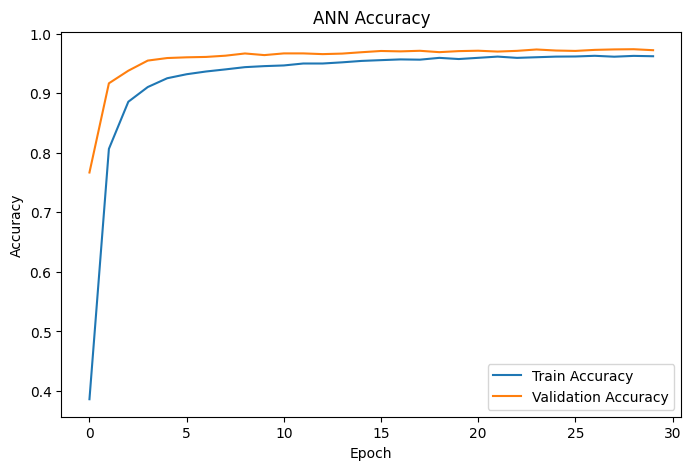

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

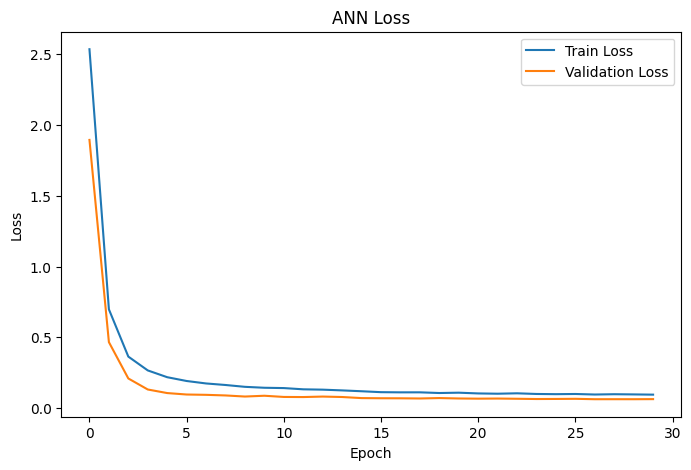

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

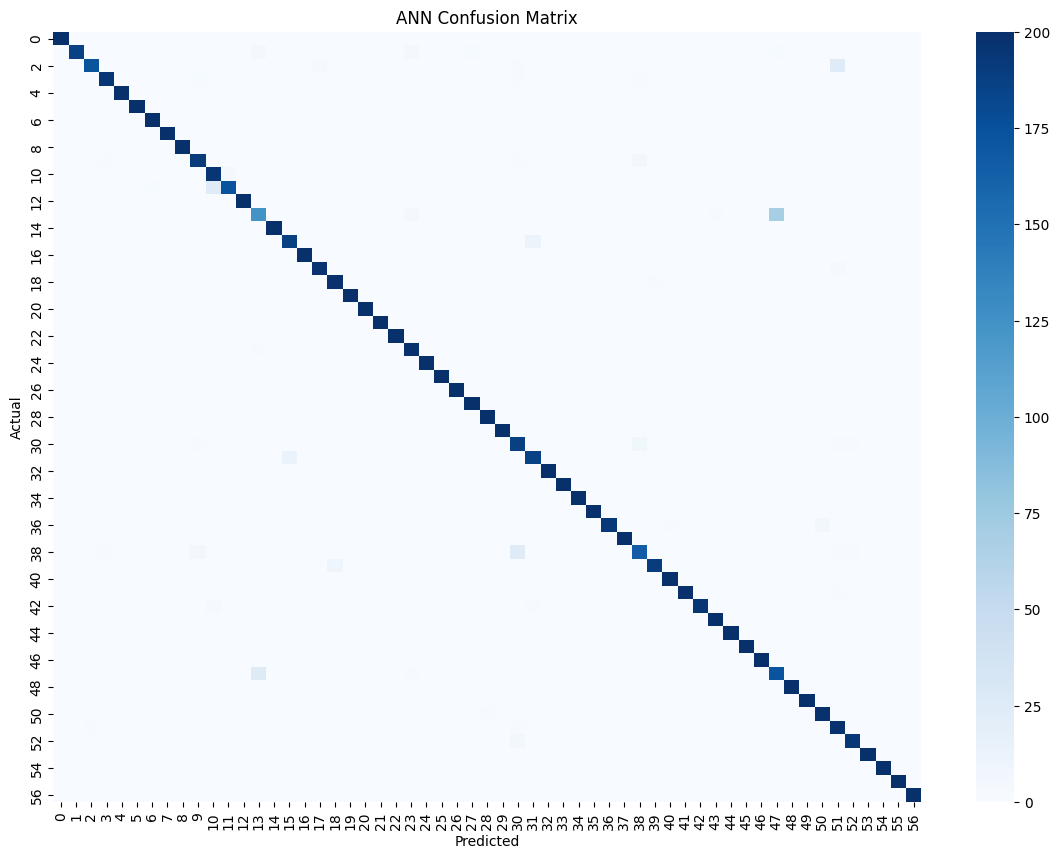

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(14,10))
sns.heatmap(cm, cmap='Blues')
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model.save("crop_recommendation_ann.keras")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train_processed.columns.tolist(), "model_columns.pkl")

print("Saved files:")
print("- crop_recommendation_ann.keras")
print("- label_encoder.pkl")
print("- scaler.pkl")
print("- model_columns.pkl")

Saved files:
- crop_recommendation_ann.keras
- label_encoder.pkl
- scaler.pkl
- model_columns.pkl


In [ ]:
##deep ml model

In [ ]:
# ==========================================
# DEEP MLP MODEL
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

deep_mlp = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_processed.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(len(np.unique(y_train)), activation='softmax')
])

deep_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 57)             │         1,881 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,497 (240.22 KB)

 Trainable params: 60,601 (236.72 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
early_stop_mlp = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_mlp = deep_mlp.fit(
    X_train_processed,
    y_train,
    validation_data=(X_test_processed, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_mlp],
    verbose=1
)

Epoch 1/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5297 - loss: 1.8339 - val_accuracy: 0.9499 - val_loss: 0.1352
Epoch 2/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8975 - loss: 0.2919 - val_accuracy: 0.9611 - val_loss: 0.1004
Epoch 3/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9167 - loss: 0.2276 - val_accuracy: 0.9608 - val_loss: 0.0981
Epoch 4/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9268 - loss: 0.1968 - val_accuracy: 0.9632 - val_loss: 0.0895
Epoch 5/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9333 - loss: 0.1800 - val_accuracy: 0.9639 - val_loss: 0.0865
Epoch 6/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9367 - loss: 0.1686 - val_accuracy: 0.9689 - val_loss: 0.0775
Epoch 7/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9417 - loss: 0.1583 - val_accuracy: 0.9674 - val_loss: 0.0799
Epoch 8/30
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9423 - loss: 0.1541 - 

In [ ]:
loss_mlp, accuracy_mlp = deep_mlp.evaluate(X_test_processed, y_test, verbose=0)
print("Deep MLP Test Loss:", loss_mlp)
print("Deep MLP Test Accuracy:", accuracy_mlp)

Deep MLP Test Loss: 0.06371696293354034
Deep MLP Test Accuracy: 0.9730702042579651


In [ ]:
y_pred_mlp = deep_mlp.predict(X_test_processed, verbose=0)
y_pred_mlp_classes = np.argmax(y_pred_mlp, axis=1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_mlp_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      0.94      0.97       200
           2       0.98      0.86      0.91       200
           3       0.99      0.98      0.99       200
           4       1.00      1.00      1.00       200
           5       1.00      1.00      1.00       200
           6       0.98      1.00      0.99       200
           7       1.00      1.00      1.00       200
           8       1.00      1.00      1.00       200
           9       0.96      0.96      0.96       200
          10       0.81      0.98      0.89       200
          11       1.00      0.76      0.86       200
          12       1.00      1.00      1.00       200
          13       0.81      0.69      0.75       200
          14       1.00      1.00      1.00       200
          15       0.94      0.94      0.94       200
          16       1.00      1.00      1.00       200
          17       1.00    

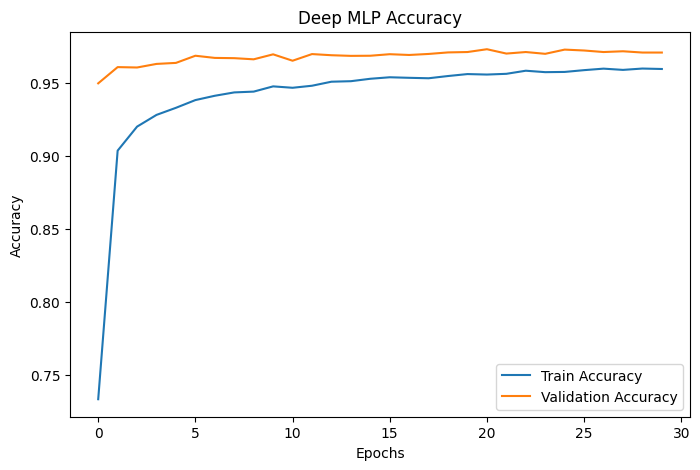

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Validation Accuracy')
plt.title('Deep MLP Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

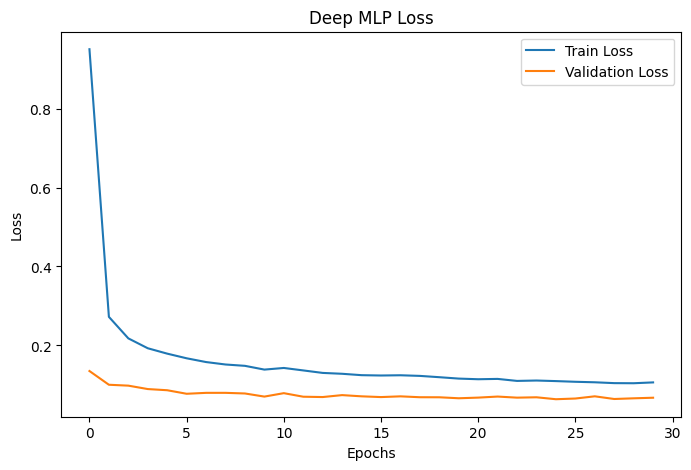

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_mlp.history['loss'], label='Train Loss')
plt.plot(history_mlp.history['val_loss'], label='Validation Loss')
plt.title('Deep MLP Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

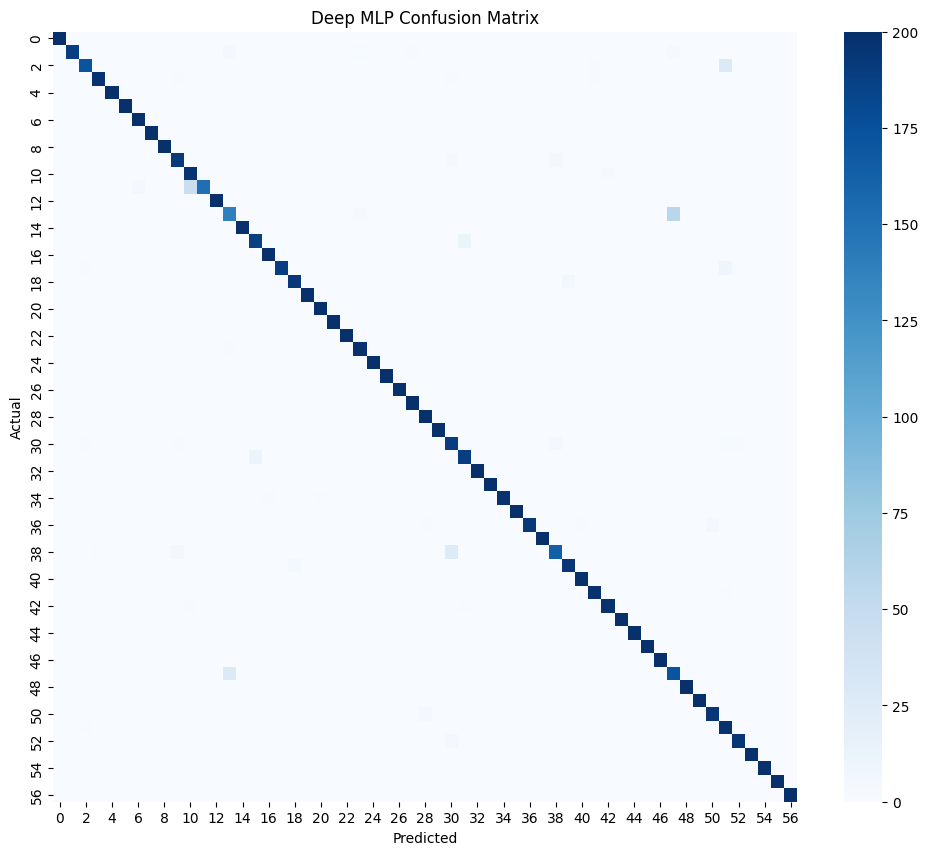

In [ ]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm_mlp, annot=False, cmap='Blues')
plt.title("Deep MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
deep_mlp.save("crop_recommendation_deep_mlp.keras")
print("Deep MLP model saved successfully!")

Deep MLP model saved successfully!


In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["ANN", "Deep MLP"],
    "Accuracy": [accuracy, accuracy_mlp],
    "Loss": [loss, loss_mlp]
})

print(model_comparison)

      Model  Accuracy      Loss
0       ANN  0.974035  0.062023
1  Deep MLP  0.973070  0.063717


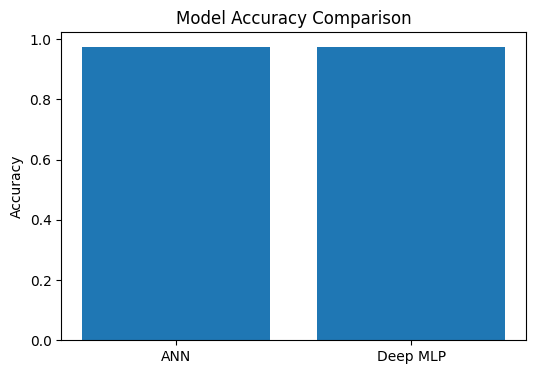

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
deep_mlp.save("deep_mlp_crop_model.keras")

print("Deep MLP model saved successfully!")

Deep MLP model saved successfully!


In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train_processed.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist"
)

In [ ]:
xgb_model.fit(X_train_processed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_processed)

In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.9836842105263158


In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      0.98      0.99       200
           2       0.97      0.93      0.95       200
           3       1.00      1.00      1.00       200
           4       1.00      1.00      1.00       200
           5       1.00      1.00      1.00       200
           6       1.00      1.00      1.00       200
           7       1.00      1.00      1.00       200
           8       1.00      1.00      1.00       200
           9       0.94      0.97      0.95       200
          10       0.97      1.00      0.98       200
          11       1.00      0.97      0.98       200
          12       1.00      1.00      1.00       200
          13       0.83      0.80      0.81       200
          14       1.00      1.00      1.00       200
          15       0.95      0.93      0.94       200
          16       1.00      1.00      1.00       200
          17       1.00    

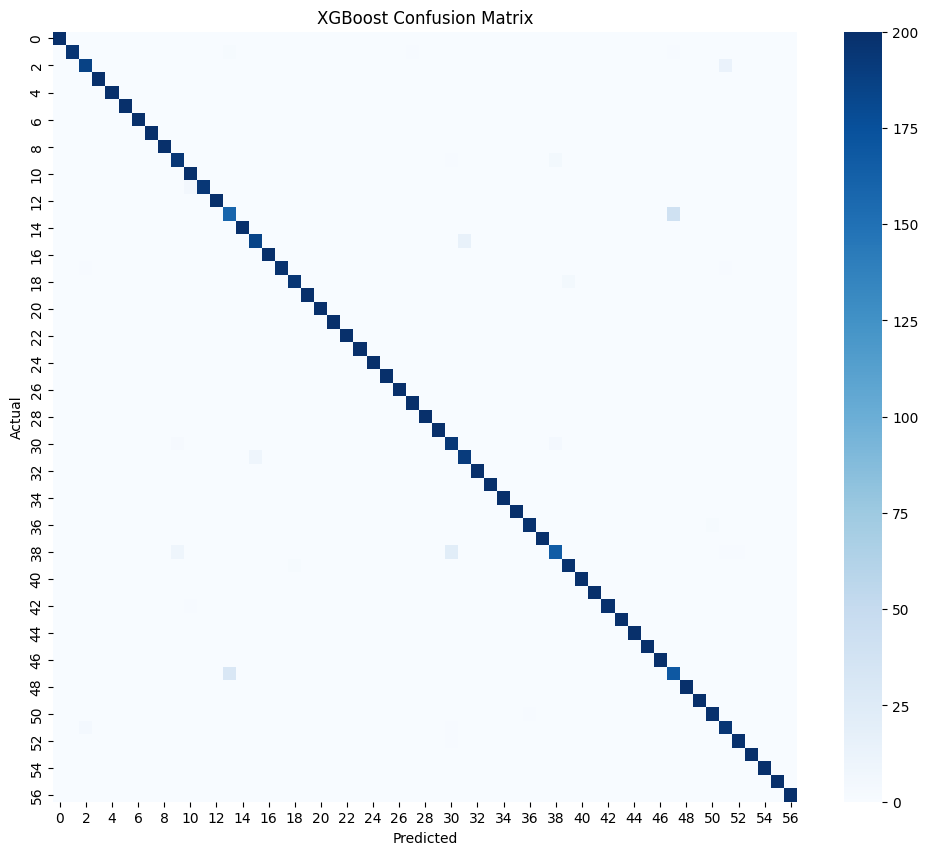

In [ ]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(12,10))
sns.heatmap(cm_xgb, cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["ANN", "Deep MLP", "XGBoost"],
    "Accuracy": [accuracy, accuracy_mlp, accuracy_xgb]
})

print(model_comparison)

      Model  Accuracy
0       ANN  0.974035
1  Deep MLP  0.973070
2   XGBoost  0.983684


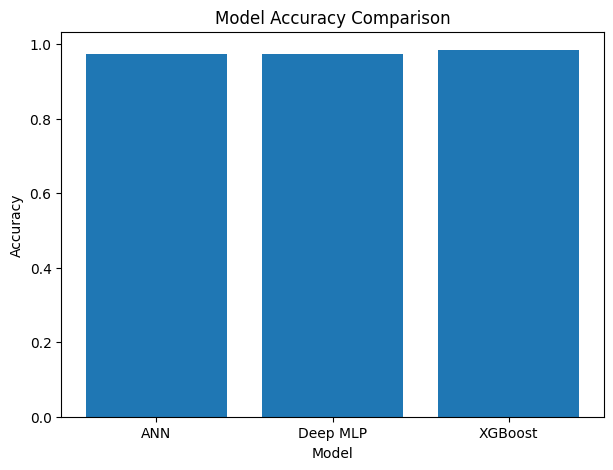

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
import joblib

# Save ANN
model.save("ann_crop_model.keras")

# Save Deep MLP
deep_mlp.save("deep_mlp_crop_model.keras")

# Save XGBoost
joblib.dump(xgb_model, "xgboost_crop_model.pkl")

# Save label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

# Save feature column order
joblib.dump(X_train_processed.columns.tolist(), "feature_columns.pkl")

print("All models saved successfully!")

All models saved successfully!


In [ ]:
from google.colab import files

files.download("ann_crop_model.keras")
files.download("deep_mlp_crop_model.keras")
files.download("xgboost_crop_model.pkl")
files.download("label_encoder.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>